# **Predicting Diabetes Status Using Machine Learning and Population Health Indicators**

## **Introduction**: Diabetes is a common public health problem that affects millions of people worldwide. Early identification of people at risk can help support prevention and timely management. This project uses machine learning to predict diabetes status based on population health indicators such as BMI, age, high blood pressure, cholesterol, physical activity, and other health and lifestyle factors. The goal is to develop and evaluate a classification model that can identify patterns associated with diabetes.

## **1. Data Preprocessing and Exploration**

### **Load and explore the dataset**

In [44]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (cross_val_score,GridSearchCV,RandomizedSearchCV)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay)


In [4]:
# Load the dataset

diabetes_data = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

In [ ]:
# Display the first 5 rows

print(diabetes_data.head())


   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

In [7]:
# Understand the sturcture and dimensions 

print(diabetes_data.info())


<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

### **Clean the dataset: Handle missing values and outliers** 

In [8]:
# Identify and handle missing values

diabetes_data.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [10]:
# Check for duplicates

diabetes_data.duplicated().sum()

np.int64(23899)

In [ ]:
# Display the duplicates by column

duplicates = diabetes_data[diabetes_data.duplicated(keep=False)]

duplicates.sort_values(
    by=list(diabetes_data.columns)).head(20)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
80704,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
152374,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
91414,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
238843,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
48850,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,8.0


In [14]:
duplicate_count = diabetes_data.duplicated().sum()

duplicate_percentage = (
    duplicate_count / len(diabetes_data)
) * 100

print("Duplicate rows:", duplicate_count)
print("Percentage:", round(duplicate_percentage, 2), "%")

Duplicate rows: 23899
Percentage: 9.42 %


#### **Comments on duplicates handling**: The dataset contained 23,899 duplicated rows, representing approximately 9.42% of the observations. Because the dataset consists of population health survey indicators and does not contain a unique respondent identifier, identical records may represent different individuals with the same health and demographic characteristics. Therefore, duplicate records were investigated before deciding whether to remove them.

In [ ]:
# Summary statistics

diabetes_data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


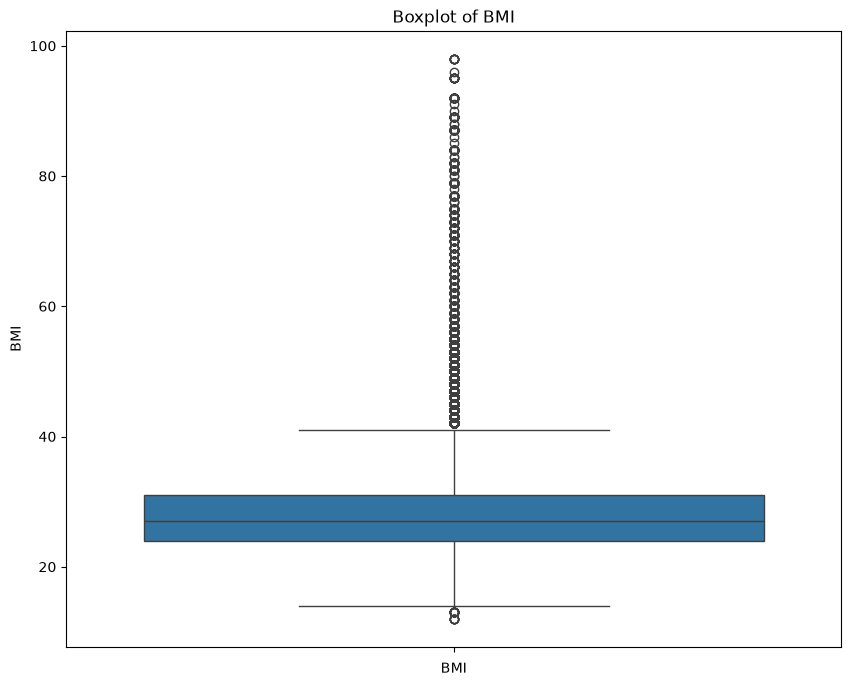

In [17]:
# Visualize BMI with a boxplot

plt.figure(figsize=(10,8))

sns.boxplot(y=diabetes_data["BMI"])
plt.title("Boxplot of BMI")
plt.xlabel("BMI")
plt.show()

In [ ]:
# print the lower and upper bound

Q1 = diabetes_data["BMI"].quantile(0.25)
Q3 = diabetes_data["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 24.0
Q3: 31.0
IQR: 7.0
Lower bound: 13.5
Upper bound: 41.5


In [21]:


bmi_outliers = diabetes_data[
    (diabetes_data["BMI"] < lower_bound) |
    (diabetes_data["BMI"] > upper_bound)]

print("Number of BMI outliers:", len(bmi_outliers))
print(
    "Percentage of BMI outliers:",
    round(len(bmi_outliers) / len(diabetes_data) * 100, 2),
    "%"
)

Number of BMI outliers: 9847
Percentage of BMI outliers: 3.88 %


**Outlier Assessment**: BMI was assessed for outliers using the interquartile range (IQR) method. A total of 9,847 observations (3.88%) were identified as potential outliers. These observations were retained because extreme BMI values may represent valid population health observations and may provide important information for predicting diabetes status.

### **Converting the outcome variable into binary**

In [ ]:
# Display the diabetes categories

diabetes_data["Diabetes_012"].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

In [30]:
# Keep only no diabetes (0) and diabetes (2)
diabetes_binary = diabetes_data[
    diabetes_data["Diabetes_012"] != 1
].copy()

In [ ]:
# Recode diabetes from 2 to 1

diabetes_binary["Diabetes_binary"] = (
    diabetes_binary["Diabetes_012"].replace({0: 0, 2: 1})
)

# Remove the original outcome variable
diabetes_binary.drop("Diabetes_012", axis=1, inplace=True)

In [ ]:
# Verify

diabetes_binary["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    213703
1.0     35346
Name: count, dtype: int64

In [34]:
# Percentage of each class

diabetes_binary["Diabetes_binary"].value_counts(normalize=True) * 100

Diabetes_binary
0.0    85.807612
1.0    14.192388
Name: proportion, dtype: float64

### **Visualize relationships in the data**

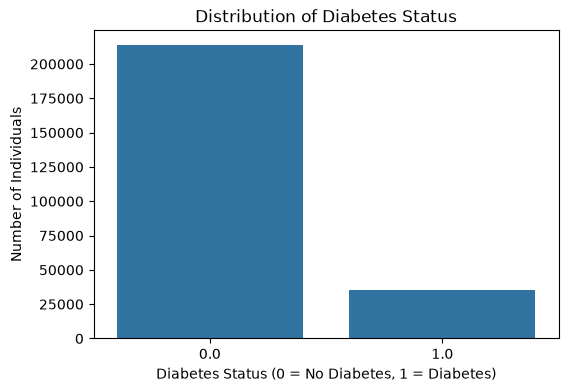

In [ ]:
# Diabetes class distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=diabetes_binary,
    x="Diabetes_binary")

plt.title("Distribution of Diabetes Status")
plt.xlabel("Diabetes Status (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Individuals")
plt.show()

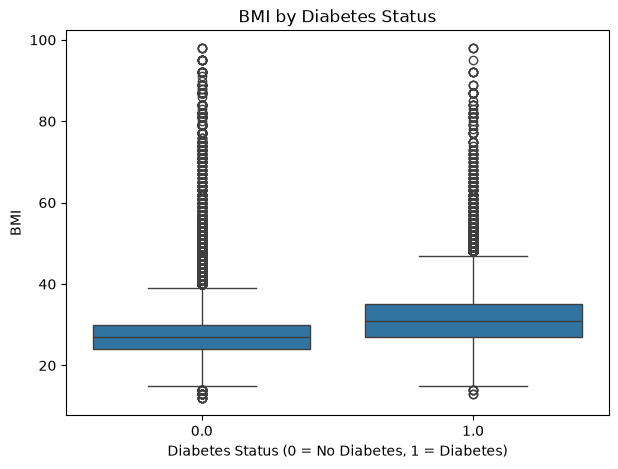

In [37]:
# BMI by diabetes status

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=diabetes_binary,
    x="Diabetes_binary",
    y="BMI"
)

plt.title("BMI by Diabetes Status")
plt.xlabel("Diabetes Status (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")
plt.show()

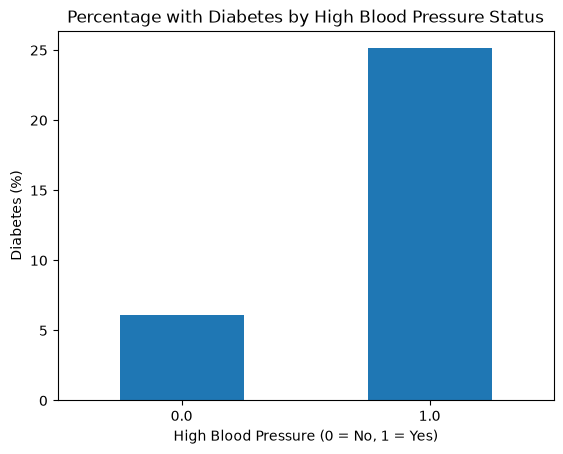

In [38]:
# High blood pressure and diabetes

bp_diabetes = (
    diabetes_binary
    .groupby("HighBP")["Diabetes_binary"]
    .mean() * 100
)

bp_diabetes.plot(kind="bar")

plt.title("Percentage with Diabetes by High Blood Pressure Status")
plt.xlabel("High Blood Pressure (0 = No, 1 = Yes)")
plt.ylabel("Diabetes (%)")
plt.xticks(rotation=0)
plt.show()

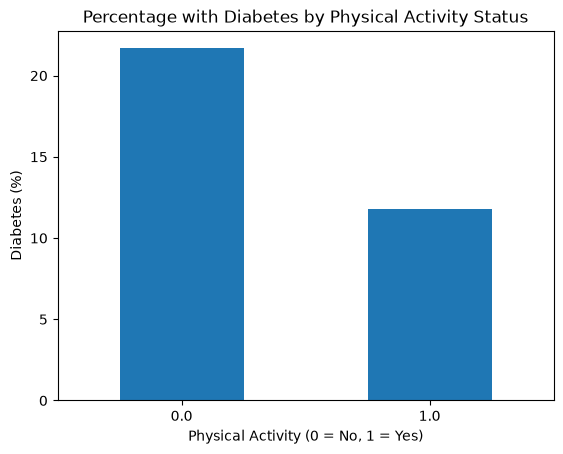

In [39]:
# Physical activity and diabetes

activity_diabetes = (
    diabetes_binary
    .groupby("PhysActivity")["Diabetes_binary"]
    .mean() * 100
)

activity_diabetes.plot(kind="bar")

plt.title("Percentage with Diabetes by Physical Activity Status")
plt.xlabel("Physical Activity (0 = No, 1 = Yes)")
plt.ylabel("Diabetes (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the sizes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

#### **Split the data into training and testing sets**

In [ ]:
# Split data into the training and testing sets

X = diabetes_binary.drop("Diabetes_binary", axis=1)
y = diabetes_binary["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

### **Scaling the variables**

In [ ]:
# Variables scaling

scale_cols = [
    'BMI', 'GenHlth', 'MentHlth', 'PhysHlth',
    'Age', 'Education', 'Income']

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [43]:
X_train.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
100695,0.0,0.0,1.0,-0.506479,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,-1.407314,-0.427924,-0.483441,0.0,0.0,-0.005188,-0.056150,-0.516114
106592,1.0,1.0,1.0,-0.051888,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,-0.469586,-0.292358,-0.483441,0.0,0.0,-0.005188,0.960419,0.451680
244739,1.0,0.0,1.0,0.251174,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.405869,-0.427924,0.092752,1.0,0.0,0.648579,0.960419,0.935576
88575,0.0,0.0,1.0,-0.658010,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.405869,-0.021224,0.092752,0.0,1.0,0.648579,0.960419,0.935576
92926,0.0,1.0,1.0,-0.203418,1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.343597,3.639074,2.973718,1.0,0.0,-0.658954,-0.056150,0.451680


In [45]:
X_test.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
42067,0.0,0.0,1.0,-0.203418,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,-0.469586,-0.427924,-0.483441,0.0,1.0,-0.332071,0.960419,0.935576
223929,0.0,1.0,1.0,0.705765,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,-1.407314,-0.427924,-0.483441,0.0,0.0,-0.658954,-0.056150,-2.451700
174799,0.0,0.0,1.0,-0.658010,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,-0.469586,-0.427924,-0.483441,0.0,0.0,-0.985838,-1.072719,0.451680
137733,0.0,0.0,1.0,-0.961071,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,-0.469586,-0.292358,-0.483441,0.0,1.0,-2.293371,-0.056150,-0.032217
133820,0.0,0.0,1.0,0.251174,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.468141,-0.427924,-0.252963,0.0,1.0,-1.639604,0.960419,0.935576


## **3. Model Selection and Development**

In [ ]:
# Train Logistic Regression before parameter tuning (Baseline)

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42)

log_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [ ]:
# Make prediction for logist regression baseline

y_pred_log_base = log_model.predict(X_test)

In [ ]:
# Evaluate the Logistic regression baseline

print("Baseline Logistic Regression")
print(classification_report(y_test, y_pred_log_base))

Baseline Logistic Regression
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.83     42741
         1.0       0.32      0.77      0.45      7069

    accuracy                           0.74     49810
   macro avg       0.64      0.75      0.64     49810
weighted avg       0.86      0.74      0.77     49810



In [49]:
# Train the Random forest for the baseline

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [50]:
# Make prediction for Random Forest baseline

y_pred_rf_base = rf_model.predict(X_test)

In [ ]:
# Evaluate the Random Forest baseline 

print("Baseline Random Forest")
print(classification_report(y_test, y_pred_rf_base))

Baseline Random Forest
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90     42741
         1.0       0.40      0.46      0.43      7069

    accuracy                           0.83     49810
   macro avg       0.65      0.67      0.66     49810
weighted avg       0.84      0.83      0.83     49810



### **Cross validation**

In [ ]:
# Cross-validation
# Logistic regression using 5-fold cross-validation

log_cv_scores = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1)

print("Logistic Regression CV F1 scores:", log_cv_scores)
print("Mean CV F1:", log_cv_scores.mean())

Logistic Regression CV F1 scores: [0.45350649 0.44773474 0.45396593 0.45109345 0.45532423]
Mean CV F1: 0.4523249685324647


In [ ]:
# Cross-validation
# Random Forets using 5-fold cross-validation

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1)

print("Random Forest CV F1 scores:", rf_cv_scores)
print("Mean CV F1:", rf_cv_scores.mean())

Random Forest CV F1 scores: [0.42688405 0.42887753 0.42310242 0.42403534 0.42799933]
Mean CV F1: 0.42617973371441


### **Hyperparameter tuning**

In [54]:
# Hyperparameter tuning: Logistic Regression

log_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']}

In [ ]:
# Run search

log_grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    param_grid=log_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

In [56]:
# Display the best results

print("Best Logistic Regression Parameters:")
print(log_grid.best_params_)

print("Best CV F1-score:")
print(log_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 0.01, 'solver': 'lbfgs'}
Best CV F1-score:
0.4524490011448951


In [57]:
# Hyperparameter tuning: Random Forest

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']}

In [58]:
# Run search

rf_random = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1)

rf_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for 

In [59]:
# Display the best parameters

print("Best Random Forest Parameters:")
print(rf_random.best_params_)

print("Best CV F1-score:")
print(rf_random.best_score_)

Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Best CV F1-score:
0.4658112029266815


### **Get the optimized model**

In [60]:
# Get the optimized model

best_log = log_grid.best_estimator_
best_rf = rf_random.best_estimator_

## **4. Model Evaluation and Optimization**

### **Make predictions on test data**

In [61]:
# Make predictions
y_pred_log = best_log.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

# Predicted probabilities for ROC-AUC
y_prob_log = best_log.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

In [62]:
print("Optimized Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("Optimized Random Forest")
print(classification_report(y_test, y_pred_rf))

Optimized Logistic Regression
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.83     42741
         1.0       0.32      0.77      0.45      7069

    accuracy                           0.74     49810
   macro avg       0.64      0.75      0.64     49810
weighted avg       0.86      0.74      0.77     49810

Optimized Random Forest
              precision    recall  f1-score   support

         0.0       0.94      0.78      0.85     42741
         1.0       0.35      0.72      0.47      7069

    accuracy                           0.77     49810
   macro avg       0.65      0.75      0.66     49810
weighted avg       0.86      0.77      0.80     49810



### **Calculate ROC-AUC**

In [63]:
# Predicted probabilities for class 1
y_prob_log = best_log.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
log_auc = roc_auc_score(y_test, y_prob_log)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression ROC-AUC:", log_auc)
print("Random Forest ROC-AUC:", rf_auc)

Logistic Regression ROC-AUC: 0.8288347634188429
Random Forest ROC-AUC: 0.831280171064878


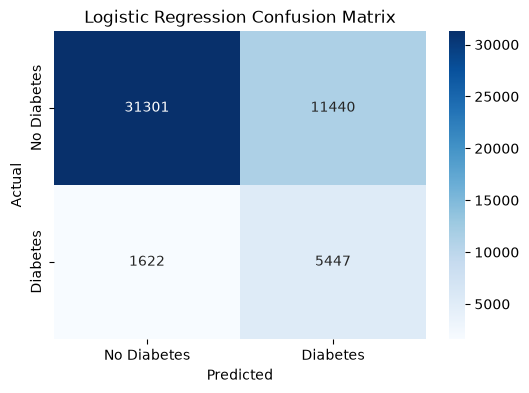

In [ ]:
# Confusion matrix for Logistic Regression

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

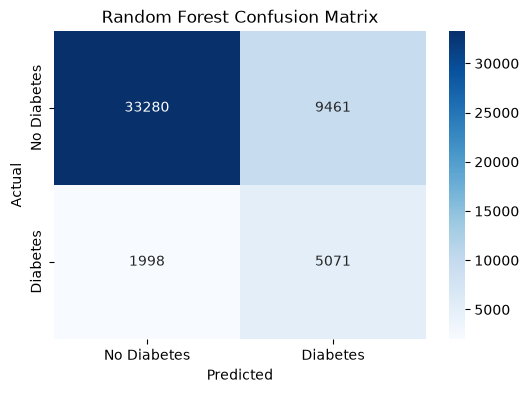

In [65]:
# Confusion matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

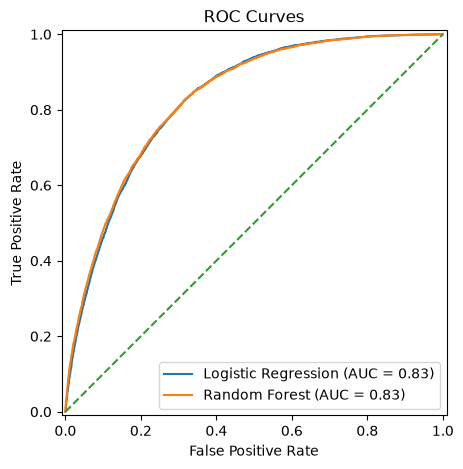

In [67]:

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name='Logistic Regression',
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name='Random Forest',
    ax=plt.gca()
)

plt.plot([0, 1], [0, 1], '--')

plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

### **Save the model**

In [68]:
import joblib

joblib.dump(best_rf, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved.")

Model and scaler saved.


In [69]:
## Save the features information

joblib.dump(list(X.columns), "feature_columns.pkl")
joblib.dump(scale_cols, "scale_columns.pkl")

['scale_columns.pkl']

### **Conclusion**: The optimized Random Forest model was selected for the demonstration interface based on its test-set accuracy of 77% and class-1 F1-score of 0.47. Logistic Regression achieved a higher class-1 recall of 77%, compared with 72% for Random Forest, while Random Forest achieved higher precision and F1-score. Both models achieved an ROC-AUC of approximately 0.83, indicating similar overall discrimination. Hyperparameter tuning improved the Random Forest's class-1 recall from 46% in the baseline model to 72% in the optimized model. 